<br>
<font>
<!-- <img src="https://sina.sharif.edu/~m_salehi/images/logo_sharif.png" alt="SUT logo" width=300 height=300 align=left class="saturate"> -->
<div dir=ltr align=center>
<img src="https://sina.sharif.edu/~m_salehi/images/logo_sharif.png" width=160 height=180>
<br>
<font color=0F5298 size=6>
Introduction to Machine Learning <br>
<font color= 6C3BAA size=6>
More on Neural Networks with PyTorch <br>
<font color=696880 size=5>
<!-- <br> -->
Computer Engineering Department
<br>
Sharif University of Technology

<font color=696880 size=5>
<br>
CE 40477 - Fall 2025

<font color=GREEN size=5>
<br>
Hossein Shahabadi & Farzan Rahmani
<!-- <br> -->

# Table of Contents

* ## [Imports and Setup](#imports-and-setup)
* ## [Loading the Data](#loading-the-data)
* ## [Neural Network](#neural-network)
* ## [Training](#training)
* ## [Evaluation](#evaluation)
* ## [Saving and Loading Models](#saving-and-loading-models)

<a id="imports-and-setup"></a>
## Imports and Setup

In this notebook we are going to work with the [MedMNIST](https://medmnist.com/) dataset. For simplicity, we are going to install medmnist so that it would be easier to work with it.

This notebook aims to solve a multi-label classification problem on medical images (specifically Chest X-Rays). The goal is to train a neural network to predict the presence or absence of 14 different disease conditions or findings from a given chest X-ray image. Unlike multi-class classification where an image belongs to only one category, in multi-label classification, an image can be associated with zero, one, or multiple conditions simultaneously. The ChestMNIST dataset provides these X-ray images and their corresponding multi-labels

In [1]:
! pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.0 MB/s eta 0:00:00


Once again we must import our libraries. Notice that we are going to use `ChestMNIST` which is a dataset of *Chest X-Rays*.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, utils
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
from tqdm import trange
from medmnist import ChestMNIST
from matplotlib import pyplot as plt
from sklearn.metrics import hamming_loss, accuracy_score, precision_recall_fscore_support, average_precision_score

In [3]:
# @title plotting helper function
def plot_results(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

To accelerate operations in the neural network, we move it to the GPU or MPS (for Apple silicon) if available.

In [4]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


<a id="loading-the-data"></a>
# Loading the Data

To work with the data we must first download the dataset using `ChestMNIST`. We will normalize our data as well to get better results during training.

In [5]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

train_dataset = ChestMNIST(split='train', transform=transform, download=True)
test_dataset = ChestMNIST(split='test', transform=transform, download=True)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

100%|██████████| 82.8M/82.8M [00:05<00:00, 14.7MB/s]


Train dataset size: 78468
Test dataset size: 22433


Next we must get the dataloaders. Perhaps you recall from our [previous notebook](https://colab.research.google.com/github/SharifiZarchi/Introduction_to_Machine_Learning/blob/main/Jupyter_Notebooks/Chapter_03_Neural_Networks/NNs_with_torch.ipynb), we didn't use validation sets. However in this notebook we are going to learn how we can use validation sets in PyTorch using `random_split` from `torch.utils.data`. In order to keep the rest of the notebooks shorter and to the point, we will not use validation sets in later notebooks.

In [6]:
# Split the dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 62774
Validation dataset size: 15694
Test dataset size: 22433


While we could now proceed with our datasets, since the [MedMNIST](https://medmnist.com/) dataset provides validation sets itself, we are going to use its data.

In [7]:
train_dataset = ChestMNIST(split='train', transform=transform, download=False)
val_dataset = ChestMNIST(split='val', transform=transform, download=True)
test_dataset = ChestMNIST(split='test', transform=transform, download=False)

print(f'Training dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Testing dataset size: {len(test_dataset)}')

Training dataset size: 78468
Validation dataset size: 11219
Testing dataset size: 22433


Same as before, we can make the dataloaders. Notice that we don't shuffle our validation and test sets but we do shuffle the training set. We groups samples into batches of 64 (batch_size=64) and shuffle the training data at the beginning of each epoch to ensure the model doesn't learn the order of samples, which helps in better generalization

In [8]:
# Create the dataloaders
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

Now lets see the dimensions of the data.

In [9]:
# Iterate over the data
for x, y in test_loader:
    print(f"Shape of X [N, C, H, W]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64, 14]) torch.int64


Let's look at some of the data to see what we are dealing with!

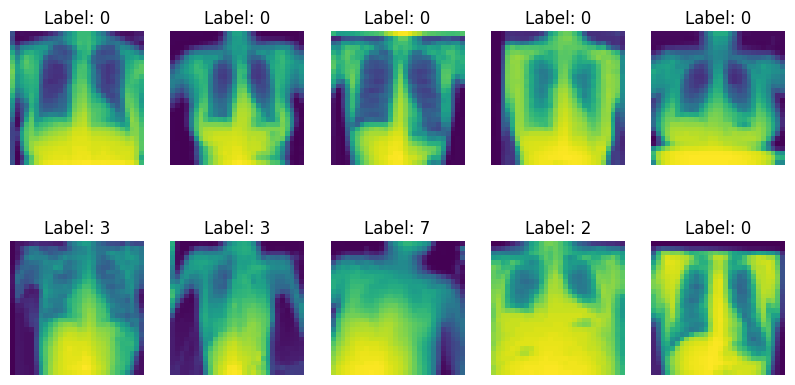

In [10]:
# Show First 10 Images

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_dataset[i][0].squeeze())
    plt.title(f"Label: {np.argmax(train_dataset[i][1])}")
    plt.axis('off')
plt.show()

<a id="neural-network"></a>
# Neural Network

This time we are going to use batch normalization layers and leaky relu activation functions.

In [11]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(128),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(64),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(64),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


<a id="training"></a>
# Training

To implement our training code more clearly, we are going to implement the following functions:


*   `train_step`: By running this function we train the model for a single epoch.
*   `test_step`: By running this function we will evaluate the models performance on the given dataloader without training the model.
*   `train_model`: This function will use the aforementioned functions to fully train the model and evaluate the results.






In [12]:
def train_step(model, criterion, optimizer, dataloader=train_loader, device=device):
    running_loss = 0
    # Move the model to training mode
    model.train()
    # Iterate over the dataloader
    for x, y in dataloader:
        # Move the datapoints to same device as the model
        x, y = x.to(device), y.to(device)
        # Clear the gradients
        optimizer.zero_grad()
        # Predict the output and perform the forward pass
        pred = model(x)
        # Compute prediction error
        loss = criterion(pred, y.float())
        # Backpropagation
        loss.backward()
        # Update the model weights
        optimizer.step()
        # Update the running loss
        running_loss += loss.item()
    # Calculate and return the average loss
    return running_loss / len(dataloader)


def test_step(model, criterion, dataloader=val_loader, device=device):
    running_loss = 0
    # Move the model to training mode
    model.eval()
    # Disable gradient calculation
    with torch.no_grad():
      # Iterate over the dataloader
      for x, y in dataloader:
          # Move the datapoints to same device as the model
          x, y = x.to(device), y.to(device)
          # Predict the output and perform the forward pass
          pred = model(x)
          # Compute prediction error
          loss = criterion(pred, y.float())
          # Update the running loss
          running_loss += loss.item()
    # Calculate and return the average loss
    return running_loss / len(dataloader)

Now we have to implement the `train_model` function.

In [14]:
def train_model(model, n_epochs, optimizer, criterion, train_loader, val_loader, device=device):
    train_losses, val_losses = [], []
    for epoch in (pbar := trange(n_epochs)):
        # Train the model
        train_loss = train_step(model, criterion, optimizer, train_loader, device)
        # Evaluate the model
        val_loss = test_step(model, criterion, val_loader, device)
        # Display the results
        pbar.set_description(f'Train Loss = {train_loss:.3f} | Val Loss = {val_loss:.3f} ')
        # Store the results
        train_losses.append(train_loss), val_losses.append(val_loss)
    # Plot the results
    plot_results(train_losses, val_losses)
    return train_losses, val_losses

All that remains for us to do is to define the loss metric and the optimizer to train the model.

In [15]:
model = SimpleNN(input_size=28*28, num_classes=14).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Train Loss = 0.161 | Val Loss = 0.165 : 100%|██████████| 20/20 [06:48<00:00, 20.44s/it]


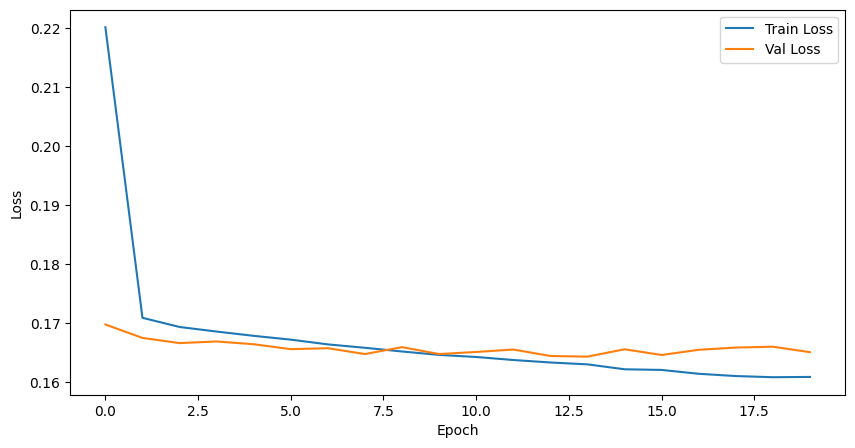

In [16]:
results = train_model(model, 20, optimizer, criterion, train_loader, val_loader)

<a id="evaluation"></a>
# Evaluation

In [23]:
def evaluate_model(model, data_loader, device=device):
    model.eval() # This line sets the model to evaluation mode.
    # This is important because it disables certain layers like dropout and
    # batch normalization that behave differently during training versus
    # evaluation
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    print('All Labels Shape:', all_labels.shape)
    print('All Predictions Shape:', all_preds.shape)

    # print the first 20 rows
    print('First 10 Labels:', all_labels[:20])
    # print('First 10 Predictions:', all_preds[:20])

    hamming = hamming_loss(all_labels, all_preds > 0.5)
    subset_acc = accuracy_score(all_labels, all_preds > 0.5)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds > 0.5, average='macro')
    avg_precision = average_precision_score(all_labels, all_preds, average='macro')

    print(f'Hamming Loss: {hamming}')
    print(f'Subset Accuracy: {subset_acc}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1-Score: {f1}')
    print(f'Average Precision: {avg_precision}')

    return {
        'Hamming Loss': hamming,
        'Subset Accuracy': subset_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Average Precision': avg_precision
    }

In [24]:
metrics = evaluate_model(model, test_loader)

All Labels Shape: (22433, 14)
All Predictions Shape: (22433, 14)
First 10 Labels: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0]]
Hamming Loss: 0.05260426285255777
Subset Accuracy: 0.5312263183702581
Precision: 0.22023624918081208
Recall: 0.009328510901675918
F1-Score: 0.016825838391156974
Average Precision: 0.1271333245884708


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<a id="saving-and-loading-models"></a>
# Saving and Loading Models

Now we turn our attention to saving and loading models. First we will save the model we just trained.

In [ ]:
# Save the model
torch.save(model.state_dict(), 'chestmnist_model.pth')

We can then load the model once again.

In [ ]:
# Load the model
net = SimpleNN(input_size=28*28, num_classes=14).to(device)
net.load_state_dict(torch.load('chestmnist_model.pth'))

If we evalute the loaded model once more, you will see that they have similar results.

In [ ]:
metrics = evaluate_model(net, test_loader, device)